<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8009/blob/main/laboratorio_4_alum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MCD8009: Data Discovery - Laboratorio 4

**Integrantes**

| N° | Código | Nombres |  Contribución (0% - 100%) |
|----|--------|---------|---------------------------|
| 1  |        |         |                           |
| 2  |        |         |                           |
| 3  |        |         |                           |
| 4  |        |         |                           |

### Indicaciones

- El laboratorio podrá resolverse de manera **individual o en equipos de hasta cuatro (4) personas**. Deberán completar los datos de todos los integrantes, y **una sola persona realizará la entrega del archivo ipynb**.

- Salvo que se indique explícitamente lo contrario, no se prohibe el uso de herramientas de Inteligencia Artificial Generativa, siempre que los integrantes comprendan y puedan explicar el proceso y los resultados obtenidos. **Las respuestas no deben consistir en transcripciones literales de resultados generados por estas herramientas, sino evidenciar comprensión del tema por parte del estudiante o del equipo.**

- En caso de utilizar herramientas de IA Generativa, cada equipo es responsable de verificar la coherencia de las respuestas presentadas. Si se detectan errores, inconsistencias o falta de comprensión, la pregunta podrá ser anulada sin derecho a reclamo.

- En todos los casos, deberá completarse la **Declaración de Uso de IA Generativa.**

- Pueden agregar libremente celdas de código o de Markdown según lo consideren conveniente.

### Declaración de uso de IA Generativa
- Indicar de manera breve la(s) herramienta(s) y/o modelo(s) de IA Generativa utilizados, especificando en qué pregunta(s) se emplearon y con qué propósito.
- En caso no se haya usado, también indicarlo.

## INICIO DEL LABORATORIO

### Parte 1: Feature engineering (5 puntos)

De la actividad grupal en clase de `Ideas de Feature engineering`, implemente 6 variables, de las cuales:
- Al menos una debe ser un encoding.
- Al menos una debe ser un escalado.
- Al menos una debe ser una discretización.
- Al menos una debe ser la creación de una nueva variable.

Además indique, para cada variable, qué técnica ha empleado.

Puede inspirarse de las propuestas de sus compañeros. (3 puntos)
- [Ideas de la sección 1](https://docs.google.com/presentation/d/1NctqdJAIoCf65jZgmKDR2ABQRB-JVE_BFyymi5K5Xss/edit?usp=sharing)
- [Ideas de la sección 2](https://docs.google.com/presentation/d/1uHzKY3laNwRZpQF5EC1UrcsbnBMnt6r1PeVImX-5gBE/edit?usp=sharing)

In [1]:
import pandas as pd
df = pd.read_csv('AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


#### Importar librerias

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

df_ames = df.copy()

#### Variable 1: Area Total Habitable

Superficie total construida y disponible para habitar, obtenida sumando `Total Bsmt SF` y `Gr Liv Area`

In [3]:
# Creación de Area Total Habitable
# Suma del área del sótano y el área sobre el suelo
df_ames['Total_SF'] = df_ames['Total Bsmt SF'] + df_ames['Gr Liv Area']

#### Variable 2: Antiguedad de la Propiedad

Determina la edad real al momento de la venta para estimar depreciación, obtenida de la diferencia entre `Yr Sold` y `Year Built`

In [4]:
# Creación de Antiguedad de la Propieda
# Año de venta menos año de construcción
df_ames['Antiguedad'] = df_ames['Yr Sold'] - df_ames['Year Built']

#### Variable 3: Tipo de Acceso

Aplicación de One-Hot Encoding a la variable `Street` para separar los tipos de acceso (Pave o Grvl)

In [5]:
# Encoding: Tipo de Acceso (Street)
# Aplicamos One-Hot Encoding para separar Pave y Grvl
df_ames = pd.get_dummies(df_ames, columns=['Street'], prefix='Street')

#### Variable 4: Calidad del Inmueble

Escalado Min-Max de la variable `Overall Qual` para normalizarla en un rango de 0 a 1 con la finalidad de facilitar las comparaciones.

In [6]:
# 4. Escalado: Calidad del Inmueble (Overall Qual)
# Normalización Min-Max para llevar el rango de 1-10 a 0-1 [1, 5]
scaler = MinMaxScaler()
df_ames['Overall_Qual_Scaled'] = scaler.fit_transform(df_ames[['Overall Qual']])

#### Variable 5: Segmentación por Número de Habitaciones

Categorización de `TotRms AbvGrd` en tres segmentos: "Pequeña", "Mediana" y "Grande"

In [9]:
# Visualizar estadisticas descriptivas de 'TotRms AbvGrd' para validar el rango numérico
# de la variable
df_ames['TotRms AbvGrd'].describe()

,TotRms AbvGrd
count,2930.000000
mean,6.443003
std,1.572964
min,2.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,15.000000


In [10]:
# Discretización: Segmentación por Número de Habitaciones
# Categorizamos 'TotRms AbvGrd' en Pequeña, Mediana y Grande
# Rango 2-15: 0-4 (Pequeña), 5-7 (Mediana), 8-15 (Grande)
df_ames['Rooms_Segment'] = pd.cut(df_ames['TotRms AbvGrd'],
                                  bins=[0, 4, 7, 15],
                                  labels=['Pequeña', 'Mediana', 'Grande'],
                                  right=True)

#### Variable 6: Baños Totales

Saber la cantidad de número de baños de la propiedad , se presume mientras mas baños tenga una casa el precio puede aumentar. Obtenida de la suma ponderada de baños completos y medio baños.

In [11]:
# Creación de Nueva Variable: Baños Totales
# Suma ponderada de baños completos y medios baños (sótano y niveles superiores) [10, 11]
df_ames['Total_Bathrooms'] = (df_ames['Full Bath'] + (0.5 * df_ames['Half Bath']) +
                              df_ames['Bsmt Full Bath'] + (0.5 * df_ames['Bsmt Half Bath']))



Ahora grafique algunos de sus nuevos features (ya sea mediante gráficos univariados o multivariados) e indique dos descubrimientos interesantes o conclusiones que le brindó esta nueva perspectiva. (2 puntos)

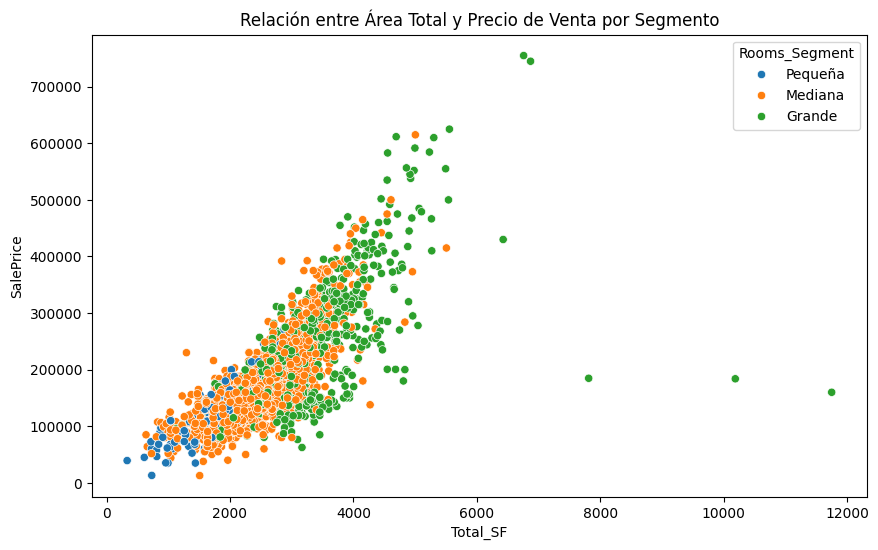

In [12]:
# Visualización de los resultados
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ames, x='Total_SF', y='SalePrice', hue='Rooms_Segment')
plt.title('Relación entre Área Total y Precio de Venta por Segmento')
plt.show()

### Parte 2: Teoría (3 puntos) [Sin uso de herramientas de IA generativa]

Responda las siguientes preguntas (1pto cada uno):

a) ¿En qué medida la sobrecarga visual puede ser contraproducente en el descubrimiento de datos? ¿Cómo se pueden minimizar este problema?

b) ¿Qué riesgos existen al basar decisiones en patrones identificados a través de Visual Data Discovery, considerando que las visualización NO son neutrales?

c) ¿Cómo se pueden mitigar los efectos de la manipulación visual en la toma de decisiones basada en datos?

### Parte 3: Trabajo integrador (12 puntos)

Este ejercicio consiste en aplicar **Visual Data Discovery** para identificar patrones en un dataset. En particular, trabajaremos con un dataset sobre **pérdidas de clientes en Telco**, una empresa del sector telecomunicaciones. El objetivo es **identificar factores de riesgo de abandono (churn)**, lo que permitirá desarrollar estrategias de **retención de clientes** y respaldar **decisiones informadas en un contexto de negocio**.  

El entregable es el notebook que presente:
- El desarrollo (proceso) del EDA (formato libre).
- Una sección ejecutiva que incluya:
    - 4 o 5 visualizaciones clave, indicando la historia que cuenta cada gráfico en relación con la problemática.
    - Al menos 3 recomendaciones estratégicas enfocándose en insights accionables, los cuales sean respaldados por las visualizaciones realizadas anteriormente.

#### **Objetivos del Análisis**  
1. Detectar patrones y segmentos de clientes con alto riesgo de churn.
2. Identificar factores críticos que contribuyen a la pérdida de clientes.
3. Proponer estrategias basadas en los hallazgos para reducir la tasa de abandono.
4. Presentar los resultados de manera clara y accionable para la toma de decisiones.
   
#### **Consideraciones para las visualizaciones**  
- Preparar visualizaciones que resalten los hallazgos clave.
- Utilizar gráficos claros y concisos, asegurándose de que respalden las recomendaciones para la toma de decisiones.  
- Aplicar buenas prácticas en visualización de datos.

#### **Consideraciones para las recomendaciones estratégicas**  
- Con base en los resultados obtenidos, desarrollar estrategias de retención específicas.  
- Justificar cómo estas recomendaciones podrían reducir el churn y el impacto que tendrían en el negocio.  

#### **Nota:**
- La calificación tomará en cuenta el orden y presentación del cuadernillo, la claridad y diseño de los gráficos, y la calidad de las recomendaciones.

In [ ]:
import pandas as pd

demographics = pd.read_csv("Telco_customer_churn_demographics.csv")
location = pd.read_csv("Telco_customer_churn_location.csv")
population = pd.read_csv("Telco_customer_churn_population.csv")
status = pd.read_csv("Telco_customer_churn_status.csv")
services = pd.read_csv("Telco_customer_churn_services.csv")